EXTRACCIÓN DE DATOS
Ruta:
C:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Processed Data\Augmented

Archivos CSV encontrados: 620
DIAGNÓSTICO DE DATOS
Archivos originales       : 620
Archivos procesados       : 580
Descartados por >4500 m   : 30
Sin trigger de despegue   : 0
Ventana insuficiente      : 10

X_temporal: (580, 201, 6)
y_temporal: (580,)
Vuelos únicos: 580


LSTM V10 
Dataset: (580, 201, 6)
Ventana: 201
Características: 6
Vuelos: 580


FOLD 1/5
Epoch 1/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 295ms/step - loss: 0.3888 - mae: 0.6423 - val_loss: 0.2574 - val_mae: 0.5227 - learning_rate: 5.0000e-04
Epoch 2/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - loss: 0.2361 - mae: 0.4337 - val_loss: 0.2279 - val_mae: 0.4783 - learning_rate: 5.0000e-04
Epoch 3/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - loss: 0.1903 - mae: 0.3605 - val_loss: 0.2081 - val_mae: 0.4491 - learning_rate: 5.0000e-04
Epoch 4/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 0.1729 - mae: 0.3323 - val_los

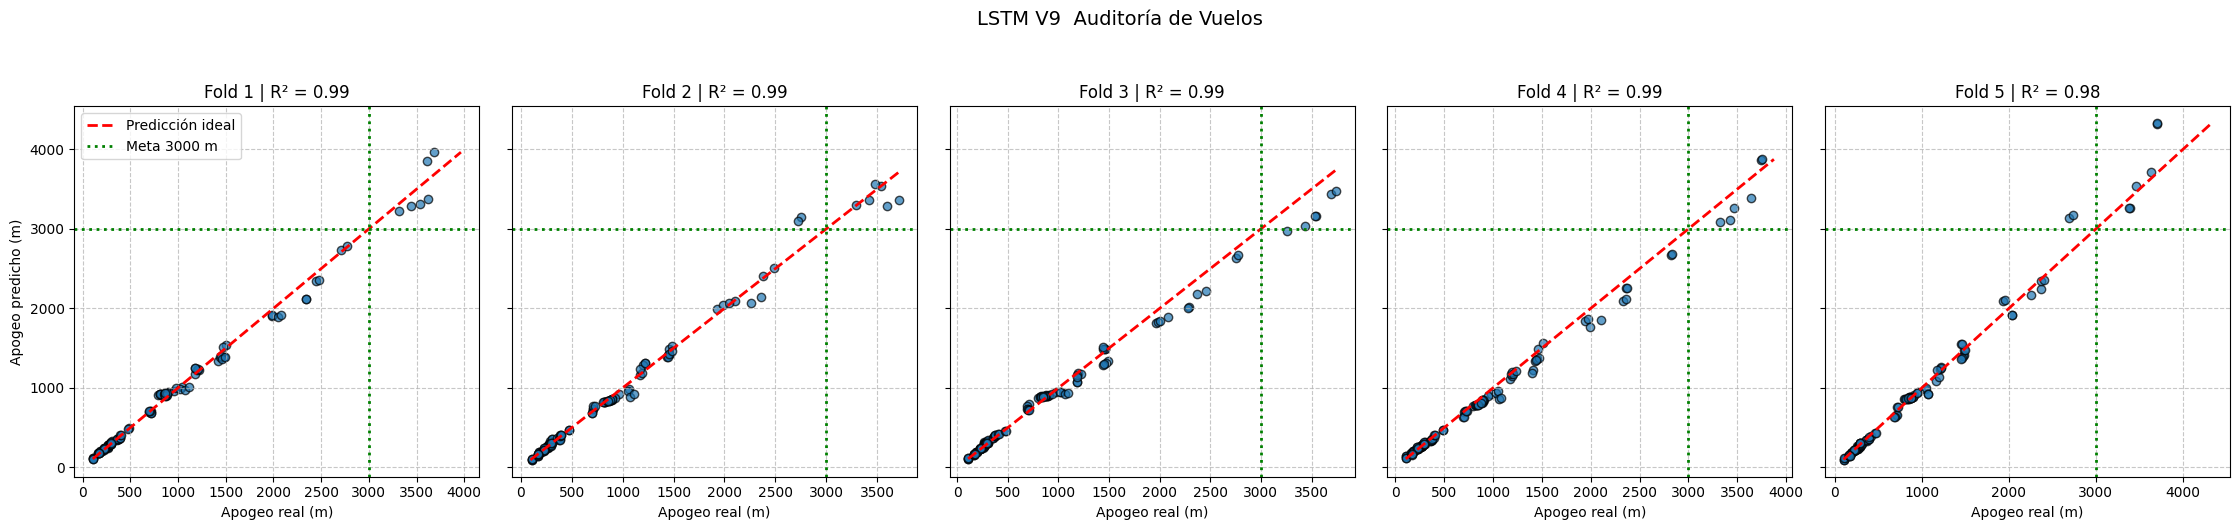

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GRU,
    Bidirectional,
    GaussianNoise,
    BatchNormalization,
    Conv1D,
    MaxPooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber
# 1. CONFIGURACIÓN
PROCESSED_PATH = Path(r"C:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Processed Data\Augmented")
WINDOW_SIZE = 201
FEATURES_LSTM = ["baro_altitude","accl_x","accl_y","accl_z","At","P"]
# 2. LOCALIZAR ARCHIVOS
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print("EXTRACCIÓN DE DATOS")
print("Ruta:")
print(PROCESSED_PATH)
print(f"\nArchivos CSV encontrados: {len(archivos_originales)}")
if len(archivos_originales) == 0:

    raise ValueError( "\nNO SE ENCONTRARON ARCHIVOS CSV.\n""Revisa que la ruta sea exactamente:\n"r"C:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Processed Data\Augmented")

# 3. EXTRACCIÓN DE SECUENCIAS
X_seq = []
y_seq = []
base_ids = []
archivos_procesados = 0
archivos_descartados_altura = 0
archivos_sin_despegue = 0
archivos_ventana_corta = 0

for archivo in archivos_originales:
    try:
        df = pd.read_csv(archivo)
        df.columns = df.columns.str.strip()
        columnas_necesarias = [ "time","baro_altitude", "accl_x","accl_y","accl_z"]
        faltantes = [c for c in columnas_necesarias if c not in df.columns ]
        if len(faltantes) > 0:
            print(
                f"\nDescartado {archivo.name}"
                f" -> faltan columnas: {faltantes}"
            )

            continue
        # Orden temporal
        df = df.sort_values("time").reset_index(drop=True)
        # Eliminar NaN en variables principales
        df = df.dropna(
            subset=["baro_altitude","accl_x","accl_y","accl_z" ]).reset_index(drop=True)

        if len(df) == 0:
            continue
        # RECONSTRUCCIÓN DE CARACTERÍSTICAS
        # Aceleración total
        if "At" not in df.columns:
            df["At"] = np.sqrt(
                df["accl_x"]**2 +
                df["accl_y"]**2 +
                df["accl_z"]**2
            )
        # Presión atmosférica
        if "P" not in df.columns:
            df["P"] = (101325.0 *(1 - 2.25577e-5 * df["baro_altitude"])**5.25588 )
        # Eliminar valores no válidos
        df = df.replace([np.inf, -np.inf],np.nan)
        df = df.dropna(
            subset=FEATURES_LSTM
        ).reset_index(drop=True)
        if len(df) == 0:
            continue
        # APOGEO REAL
        apogeo_real = float(
            df["baro_altitude"].max()
        )
        # Filtro físico
        if apogeo_real > 4500:
            archivos_descartados_altura += 1
            continue
        # Evitar objetivos absurdos o negativos
        if apogeo_real <= 0:
            continue
        # TRIGGER DE DESPEGUE
        despegues = df.index[df["At"] > 15]
        if len(despegues) == 0:
            archivos_sin_despegue += 1
            continue
        idx_despegue = int(
            despegues[0]
        )
        # EXTRAER VENTANA
        window = df.iloc[
            idx_despegue:
            idx_despegue + WINDOW_SIZE
        ]
        if len(window) != WINDOW_SIZE:
            archivos_ventana_corta += 1
            continue
        # GUARDAR
        X_seq.append(
            window[FEATURES_LSTM].values
        )
        y_seq.append(
            apogeo_real
        )
        base_ids.append(
            archivo.stem
        )
        archivos_procesados += 1
    except Exception as e:
        print(
            f"\nError procesando {archivo.name}: {e}"
        )
# 4. CONVERTIR A NUMPY
X_temporal = np.array(
    X_seq,
    dtype=np.float32
)
y_temporal = np.array(
    y_seq,
    dtype=np.float32
)
flight_ids_temporal = np.array(
    base_ids
)
# 5. DIAGNÓSTICO DE DATOS
print("DIAGNÓSTICO DE DATOS")
print(f"Archivos originales       : {len(archivos_originales)}")
print(f"Archivos procesados       : {archivos_procesados}")
print(f"Descartados por >4500 m   : "f"{archivos_descartados_altura}")
print(f"Sin trigger de despegue   : "f"{archivos_sin_despegue}")
print(f"Ventana insuficiente      : "f"{archivos_ventana_corta}")
print(f"\nX_temporal: {X_temporal.shape}")
print(f"y_temporal: {y_temporal.shape}")
print(f"Vuelos únicos: "f"{len(np.unique(flight_ids_temporal))}")
# 6. PROTECCIÓN CONTRA DATASET VACÍO
if len(X_temporal) == 0:

    raise ValueError(
        "\nERROR: X_temporal está vacío.\n\n"
        "El problema está en la extracción de los CSV, "
        "no en la red neuronal.\n\n"
        "Revisa principalmente:\n"
        "1. La ruta.\n"
        "2. Las columnas de los CSV.\n"
        "3. El trigger At > 15.\n"
        "4. Que existan al menos 201 muestras después del despegue."
    )
# 7. TRANSFORMACIÓN DEL OBJETIVO
y_temporal_log = np.log1p(y_temporal)
# 8. GRUPOS POR VUELO
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Menos de 3 vuelos.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal
# 9. MODELO V10
def build_gru_v10(input_shape):
    model = Sequential(name="GRU_V10")
    model.add(Input(shape=input_shape))
    model.add(GaussianNoise(0.01))
    model.add(Conv1D(filters=64, kernel_size=3, activation="relu", padding="causal"))  # <- causal, no "same"
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(GRU(128, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dense(32, activation="relu", kernel_regularizer=l2(0.0005)))
    model.add(Dropout(0.15))
    model.add(Dense(1))

    optimizer = tf.keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=["mae"])
    return model
# 10. VALIDACIÓN GROUP K-FOLD
def groupkfold_evaluate_lstm(build_fn,X,y,groups,n_splits=5,epochs=120,batch_size=32,patience=20):
    n_splits = min(n_splits,len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X,y,groups)):
        tf.keras.backend.clear_session()
        print("\n" + "=" * 60)
        print(
            f"FOLD {fold + 1}/{n_splits}"
        )
        print("=" * 60)
        # DATOS DEL FOLD
        X_train_f = X[train_idx]
        X_val_f = X[val_idx]
        y_train_f = y[ train_idx]
        y_val_f = y[val_idx]
        # ESCALADO X
        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(
            X_train_f.reshape(
                -1,
                n_features
            )
        ).reshape(
            X_train_f.shape
        )
        X_val_scaled = scaler_X.transform(
            X_val_f.reshape(
                -1,
                n_features
            )
        ).reshape(
            X_val_f.shape
        )
        # ESCALADO Y
        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(
            y_train_f.reshape(
                -1,
                1
            )
        ).ravel()
        y_val_scaled = scaler_y.transform(
            y_val_f.reshape(
                -1,
                1
            )
        ).ravel()
        # CREAR MODELO
        model = build_fn(
            input_shape=(
                X_train_scaled.shape[1],
                X_train_scaled.shape[2]
            )
        )
        # CALLBACKS
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1
        )
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-5,
            verbose=1
        )
        # ENTRENAMIENTO
        history = model.fit(
            X_train_scaled,
            y_train_scaled,
            validation_data=(
                X_val_scaled,
                y_val_scaled
            ),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[
                early_stop,
                reduce_lr
            ],
            verbose=1
        )
        # PREDICCIÓN
        preds_scaled = model.predict(
            X_val_scaled,
            verbose=0
        ).ravel()
        # DESHACER ESCALADO
        y_pred_log = scaler_y.inverse_transform(
            preds_scaled.reshape(
                -1,
                1
            )
        ).ravel()
        # VOLVER A METROS
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)
        # Evitar predicciones negativas
        y_pred_metros = np.maximum(y_pred_metros,0)
        # MÉTRICAS
        mae = mean_absolute_error(
y_true_metros,
            y_pred_metros
        )
        rmse = np.sqrt(
            mean_squared_error(
                y_true_metros,
                y_pred_metros
            )
        )
        r2 = r2_score(
            y_true_metros,
            y_pred_metros
        )
        print("\nRESULTADOS FOLD")
        print(f"MAE  : {mae:.2f} m")
        print( f"RMSE : {rmse:.2f} m")
        print( f"R2  : {r2:.4f}")
        fold_metrics.append(
            {"MAE": mae,"RMSE": rmse,"R2": r2,"y_true": y_true_metros,"y_pred": y_pred_metros,"history": history })
    return fold_metrics
# 11. RESUMEN
def summarize_cv(fold_metrics,name):
    maes = [m["MAE"]for m in fold_metrics]
    rmses = [m["RMSE"]for m in fold_metrics]
    r2s = [m["R2"]for m in fold_metrics]
    print("\n")
    print("=" * 60)
    print(
        f"RESUMEN {name}"
    )
    print("=" * 60)
    print(f"MAE  : "f"{np.mean(maes):.2f} "f"± {np.std(maes):.2f} m")
    print(f"RMSE : "f"{np.mean(rmses):.2f} "f"± {np.std(rmses):.2f} m")
    print( f"R2   : "f"{np.mean(r2s):.4f}")
    print("=" * 60)
# 12. GRÁFICAS
def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(
        1,
        n_folds,
        figsize=(
            4.5 * n_folds,
            5
        ),
        sharey=True
    )
    if n_folds == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i][ "R2"]
        ax.scatter(y_true,y_pred,alpha=0.7,c="#1f77b4",edgecolors="k")
        min_val = min(np.min(y_true),np.min(y_pred))
        max_val = max(np.max(y_true),np.max(y_pred))
        ax.plot([min_val, max_val],[min_val, max_val],"r--",lw=2,label="Predicción ideal")
        ax.axvline(3000,color="green",linestyle=":",lw=2,label="Meta 3000 m")
        ax.axhline(3000,color="green",linestyle=":",lw=2)
        ax.set_title(f"Fold {i + 1} | R² = {r2:.2f}")
        ax.set_xlabel("Apogeo real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo predicho (m)")
            ax.legend()
        ax.grid( True,linestyle="--",alpha=0.7)
    plt.suptitle("LSTM V9  Auditoría de Vuelos",fontsize=14,y=1.05)
    plt.tight_layout()
    plt.show()
# 13. EJECUCIÓN
print("\n")
print("LSTM V10 ")
print(f"Dataset: {X_temporal.shape}")
print(f"Ventana: {WINDOW_SIZE}")
print(f"Características: {len(FEATURES_LSTM)}")
print(f"Vuelos: {len(unique_base_ids)}")

cv_lstm_v10_folds = groupkfold_evaluate_lstm(
    build_fn=build_gru_v10,
    X=X_temporal,
    y=y_temporal_log,
    groups=grupos_kfold,
    n_splits=5,
    epochs=120,
    batch_size=32,
    patience=20
)
# 14. RESULTADOS
summarize_cv(
    cv_lstm_v10_folds,
    "LSTM V10"
)
# 15. GRÁFICAS
plot_kfold_diagnostics(
    cv_lstm_v10_folds
)